In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install numpy
!pip install matplotlib pillow

# Dataset Loading and Overview

In [2]:
import pandas as pd
train_labels = pd.read_csv("labels.csv")
train_labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [3]:
print("Train images:", len(pd.read_csv("data/train/labels.csv")))
print("Test images:", len(pd.read_csv("data/test/labels.csv")))

Train images: 7200
Test images: 3600


In [4]:
print(train_labels['has_traffic_light'].value_counts())
print(train_labels['has_pedestrian'].value_counts())
print(train_labels['has_vehicle'].value_counts())

has_traffic_light
True     5276
False    1924
Name: count, dtype: int64
has_pedestrian
False    5482
True     1718
Name: count, dtype: int64
has_vehicle
True     5458
False    1742
Name: count, dtype: int64


In [5]:
import os
print(os.getcwd())

C:\Users\ASUS\Python


In [6]:
print(os.listdir())


['.ipynb_checkpoints', 'data', 'Exercise-3.ipynb', 'exercise-5 .ipynb', 'Exercise-6.ipynb', 'fog_data', 'labels.csv', 'machine learning.ipynb', 'night_data', 'pedestrian_model.pth', 'ped_model.pth', 'ped_model_v2.pth', 'poisoned_labels.csv', 'test-town-01', 'test.zip', 'traffic_light_model.pth', 'traffic_model.pth', 'train.zip', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'Untitled5.ipynb', 'Untitled6.ipynb', 'vehicle_model.pth']


In [7]:
print(os.listdir("data/train"))

['.hydra', 'actions.feather', 'carla.log', 'collisions.feather', 'gnss.feather', 'imu.feather', 'labels.csv', 'labels.feather', 'labels_fixed.csv', 'rgb-front', 'segmentation-front', 'sim.log', 'weather.feather']


In [8]:
os.listdir()

['.ipynb_checkpoints',
 'data',
 'Exercise-3.ipynb',
 'exercise-5 .ipynb',
 'Exercise-6.ipynb',
 'fog_data',
 'labels.csv',
 'machine learning.ipynb',
 'night_data',
 'pedestrian_model.pth',
 'ped_model.pth',
 'ped_model_v2.pth',
 'poisoned_labels.csv',
 'test-town-01',
 'test.zip',
 'traffic_light_model.pth',
 'traffic_model.pth',
 'train.zip',
 'Untitled.ipynb',
 'Untitled1.ipynb',
 'Untitled2.ipynb',
 'Untitled3.ipynb',
 'Untitled4.ipynb',
 'Untitled5.ipynb',
 'Untitled6.ipynb',
 'vehicle_model.pth']

In [9]:
print(os.listdir("data/train"))

['.hydra', 'actions.feather', 'carla.log', 'collisions.feather', 'gnss.feather', 'imu.feather', 'labels.csv', 'labels.feather', 'labels_fixed.csv', 'rgb-front', 'segmentation-front', 'sim.log', 'weather.feather']


In [10]:
t=pd.read_csv("data/train/labels.csv")

In [11]:
test=pd.read_csv("data/test/labels.csv")

In [12]:
print("training images:", len(t))
print("testing images:", len(test))

training images: 7200
testing images: 3600


In [13]:
print(t[["has_pedestrian", "has_traffic_light", "has_vehicle"]].value_counts())

has_pedestrian  has_traffic_light  has_vehicle
False           True               True           3040
True            True               True           1125
False           False              True           1063
                True               False           832
                False              False           547
True            True               False           279
                False              True            230
                                   False            84
Name: count, dtype: int64


In [14]:
print(t.columns)

Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')


In [15]:
t[['has_pedestrian', 'has_traffic_light', 'has_vehicle']].value_counts()

has_pedestrian  has_traffic_light  has_vehicle
False           True               True           3040
True            True               True           1125
False           False              True           1063
                True               False           832
                False              False           547
True            True               False           279
                False              True            230
                                   False            84
Name: count, dtype: int64

In [16]:
print(t['has_traffic_light'].value_counts())

has_traffic_light
True     5276
False    1924
Name: count, dtype: int64


In [17]:
print(t['has_pedestrian'].value_counts())

has_pedestrian
False    5482
True     1718
Name: count, dtype: int64


In [18]:
print(t['has_vehicle'].value_counts())

has_vehicle
True     5458
False    1742
Name: count, dtype: int64


In [19]:
import matplotlib.pyplot as plt
from PIL import Image

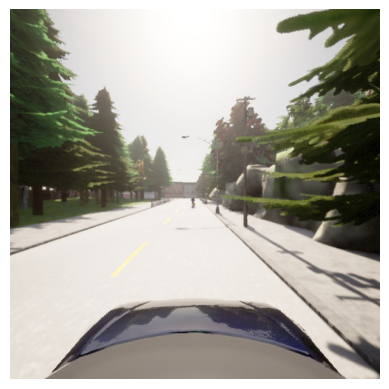

In [20]:
img = Image.open('data/train/rgb-front/000000.jpg')
plt.imshow(img)
plt.axis('off')
plt.show()

In [21]:
t.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [22]:
import matplotlib.pyplot as plt
import os
from PIL import Image

def show_images(df, condition, title):
    samples = df[condition].head(5)   # take first 5 matching rows

    plt.figure(figsize=(12, 4))

    for i, row in enumerate(samples.itertuples()):
        img_path = os.path.join("data/train/images", row.image)
        img = Image.open(img_path)

        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

In [23]:
import matplotlib.pyplot as plt
import os
from PIL import Image

def show_images(t, condition, title):
    samples = t[condition].head(5)

    plt.figure(figsize=(12, 4))

    for i, row in enumerate(samples.itertuples()):
        img_path = os.path.join("data/train/images", row.image)
        img = Image.open(img_path)

        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

In [24]:
t.head()


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [25]:
sample_rows = train_labels.sample(5)
sample_rows.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
1621,16210,False,False,True,20,0,78
1900,19000,True,False,True,3613,0,1483
6795,67950,True,True,True,92,231,9504
5477,54770,True,False,True,191,0,3886
2971,29710,True,False,False,312,7,0


# Sample Image Visualization

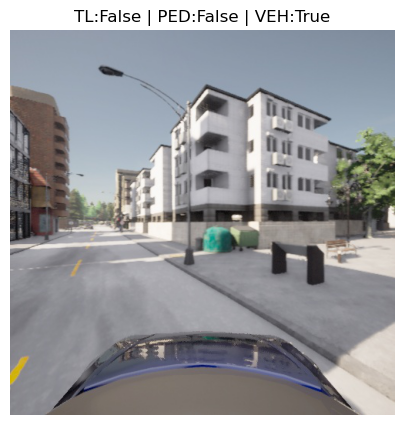

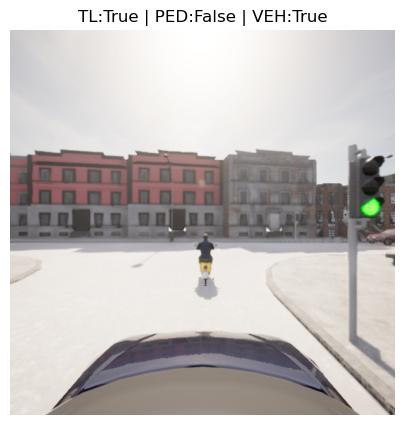

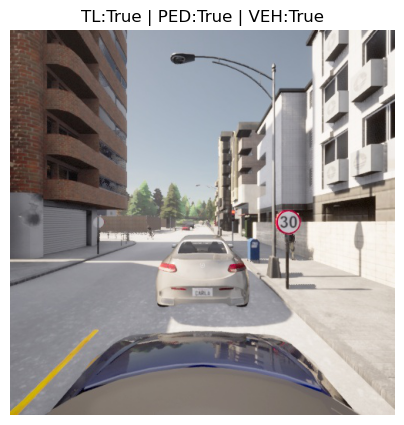

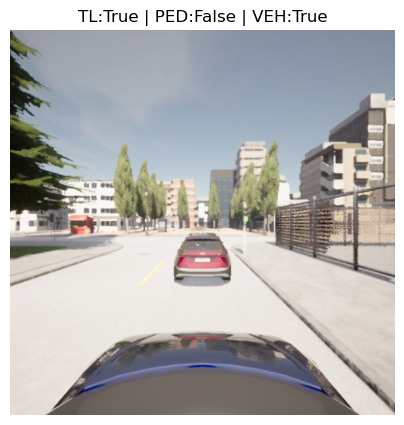

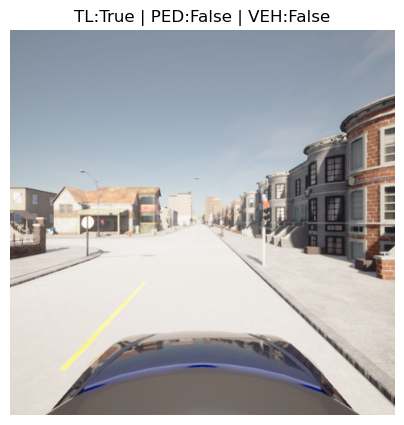

In [26]:
for _, row in sample_rows.iterrows():
    
    frame = str(row['frame']).zfill(6)
    
    img = Image.open(f"data/train/rgb-front/{frame}.jpg")

    plt.figure(figsize=(5, 5))
    plt.imshow(img)

    title = f"TL:{row['has_traffic_light']} | PED:{row['has_pedestrian']} | VEH:{row['has_vehicle']}"
    plt.title(title)

    plt.axis('off')
    plt.show()

# Exercise 3.5: Train Three Binary Classifiers

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
class CarlaDataset(Dataset):

    def __init__(self, dataframe, img_dir, label_column, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        frame = str(row['frame']).zfill(6)
        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")
        label = float(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
df = pd.read_csv("data/train/labels.csv")



train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [5]:
train_ped = CarlaDataset(train_df, "data/train/rgb-front", "has_pedestrian", transform)
val_ped   = CarlaDataset(val_df, "data/train/rgb-front", "has_pedestrian", transform)

train_veh = CarlaDataset(train_df, "data/train/rgb-front", "has_vehicle", transform)
val_veh   = CarlaDataset(val_df, "data/train/rgb-front", "has_vehicle", transform)

train_tl = CarlaDataset(train_df, "data/train/rgb-front", "has_traffic_light", transform)
val_tl   = CarlaDataset(val_df, "data/train/rgb-front", "has_traffic_light", transform)

In [6]:
train_ped_loader = DataLoader(train_ped, batch_size=32, shuffle=True)
val_ped_loader   = DataLoader(val_ped, batch_size=32, shuffle=False)

train_veh_loader = DataLoader(train_veh, batch_size=32, shuffle=True)
val_veh_loader   = DataLoader(val_veh, batch_size=32, shuffle=False)

train_tl_loader = DataLoader(train_tl, batch_size=32, shuffle=True)
val_tl_loader   = DataLoader(val_tl, batch_size=32, shuffle=False)

In [7]:
def get_model():
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(device)

In [8]:
def train_model(model, train_loader, val_loader, epochs=5):

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device).unsqueeze(1)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

    return model, train_losses, val_losses

In [9]:
ped_model = get_model()
veh_model = get_model()
tl_model  = get_model()

ped_model, ped_train_loss, ped_val_loss = train_model(ped_model, train_ped_loader, val_ped_loader)
veh_model, veh_train_loss, veh_val_loss = train_model(veh_model, train_veh_loader, val_veh_loader)
tl_model, tl_train_loss, tl_val_loss     = train_model(tl_model, train_tl_loader, val_tl_loader)

C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train=0.5249, Val=0.6131
Epoch 2: Train=0.4518, Val=0.5112
Epoch 3: Train=0.4087, Val=0.5428
Epoch 4: Train=0.3689, Val=0.3975
Epoch 5: Train=0.3182, Val=0.3537
Epoch 1: Train=0.3511, Val=0.5360
Epoch 2: Train=0.2489, Val=0.2629
Epoch 3: Train=0.2191, Val=0.2422
Epoch 4: Train=0.1856, Val=0.2133
Epoch 5: Train=0.1742, Val=0.2188
Epoch 1: Train=0.1931, Val=0.1175
Epoch 2: Train=0.1073, Val=0.0912
Epoch 3: Train=0.0708, Val=0.1439
Epoch 4: Train=0.0576, Val=0.1179
Epoch 5: Train=0.0443, Val=0.1464


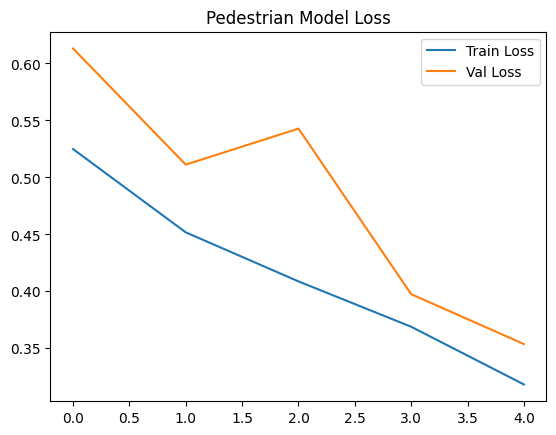

In [10]:
import matplotlib.pyplot as plt

plt.plot(ped_train_loss, label="Train Loss")
plt.plot(ped_val_loss, label="Val Loss")
plt.title("Pedestrian Model Loss")
plt.legend()
plt.show()

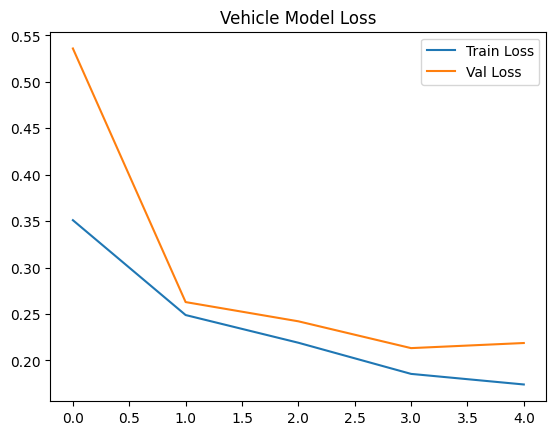

In [11]:
plt.plot(veh_train_loss, label="Train Loss")
plt.plot(veh_val_loss, label="Val Loss")
plt.title("Vehicle Model Loss")
plt.legend()
plt.show()

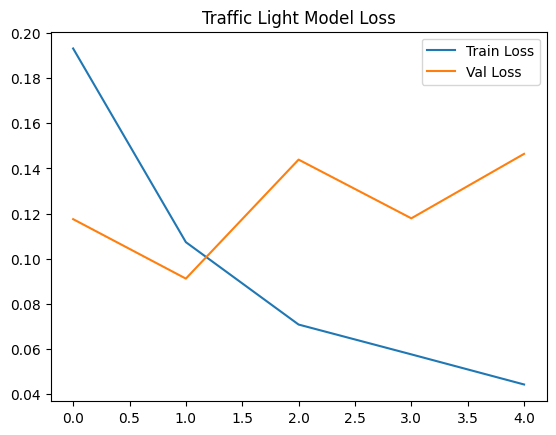

In [12]:
plt.plot(tl_train_loss, label="Train Loss")
plt.plot(tl_val_loss, label="Val Loss")
plt.title("Traffic Light Model Loss")
plt.legend()
plt.show()

In [13]:
def evaluate(model, loader):

    model.eval()

    preds = []
    labels_all = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = torch.sigmoid(model(images))
            predictions = (outputs > 0.5).float()

            preds.extend(predictions.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    print("Accuracy :", accuracy_score(labels_all, preds))
    print("Precision:", precision_score(labels_all, preds))
    print("Recall   :", recall_score(labels_all, preds))
    print("F1 Score :", f1_score(labels_all, preds))

In [14]:
print("PED MODEL")
evaluate(ped_model, val_ped_loader)

print("\nVEHICLE MODEL")
evaluate(veh_model, val_veh_loader)

print("\nTRAFFIC LIGHT MODEL")
evaluate(tl_model, val_tl_loader)

PED MODEL
Accuracy : 0.8541666666666666
Precision: 0.7956521739130434
Recall   : 0.5289017341040463
F1 Score : 0.6354166666666666

VEHICLE MODEL
Accuracy : 0.9076388888888889
Precision: 0.9450139794967382
Recall   : 0.9319852941176471
F1 Score : 0.9384544192503471

TRAFFIC LIGHT MODEL
Accuracy : 0.9513888888888888
Precision: 0.9453053783044667
Recall   : 0.9904489016236867
F1 Score : 0.9673507462686567


The pedestrian model performs the worst, mainly due to its lower recall (0.5289) and F1-score (0.6354). This indicates it misses many true pedestrian cases. This is likely because pedestrians have higher variability in shape, size, and appearance, and may be underrepresented or less diverse in the training data compared to vehicles and traffic lights.

# From a safety perspective

For the pedestrian model, recall is most important because missing a pedestrian can lead to serious safety risks. For the vehicle model, both precision and recall are important, but precision helps avoid false alarms. For the traffic light model, recall is critical to ensure signals are not missed, as shown by its already high recall (0.99).

# 3.7 

The training dataset consists of simulated CARLA driving scenes that mainly represent controlled urban environments. The data largely includes clear daytime conditions with stable lighting and good visibility. Most scenes contain structured road layouts such as city streets and intersections, with typical traffic participants including vehicles, pedestrians, and traffic lights. Environmental variation is limited, with only minor changes in brightness and shadows, while extreme conditions such as fog, heavy rain, snow, or nighttime driving are largely absent or not significantly represented.

When comparing this dataset to the originally defined Operational Design Domain (ODD), several gaps become evident. The training data does not fully cover important ODD dimensions such as nighttime scenarios, adverse weather conditions, rural or highway environments, and rare or complex edge cases like accidents or construction zones. As a result, the dataset only partially represents the full intended ODD and is biased toward simple urban daytime driving conditions.

This gap has important safety implications for the trained models. Since the models have not been exposed to many ODD-relevant conditions, their performance in unseen environments cannot be guaranteed. In particular, the models may fail under domain shift conditions such as fog, night, or unusual traffic situations, and may rely on spurious correlations specific to the training environment, such as lighting or background features. Therefore, no reliable safety claims can be made for ODD conditions that are not represented in the training data.

Overall, the analysis shows that the training data covers only a limited subset of the intended ODD, and significant gaps exist in weather diversity, lighting variation, and environmental complexity. These limitations restrict the safe deployment of the models to a narrow operational range, and further work is required to improve ODD coverage and robustness in future exercises.